### Install required libraries

Using torchaudio==2.8 here as 2.9 forces the use of torchcodec:

In [41]:
%pip install pandas numpy matplotlib torch torchaudio==2.8 soundfile -q

Note: you may need to restart the kernel to use updated packages.


### Imports

In [42]:
import glob
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchaudio
from IPython.display import Audio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

from src.audio_dataset import AudioDataset
from src.cnn_model import AudioClassifier
from src.preprocessing import get_waveform_transformer, get_spectrogram_transformer, get_cnn_pipeline
from src.utils import get_random_audio

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [43]:
INPUT_DIR = 'data'
MODEL_PATH = 'models/best_cnn.pth'

# Audio
ORIGINAL_SAMPLE_RATE = 48_000
TARGET_SAMPLE_RATE = 16_000
TARGET_AUDIO_LENGTH = 0.84
TARGET_SAMPLES = int(TARGET_SAMPLE_RATE * TARGET_AUDIO_LENGTH)
NUM_MELS = 64

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 10

### Setting up device to use

In [44]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Visualising audio data

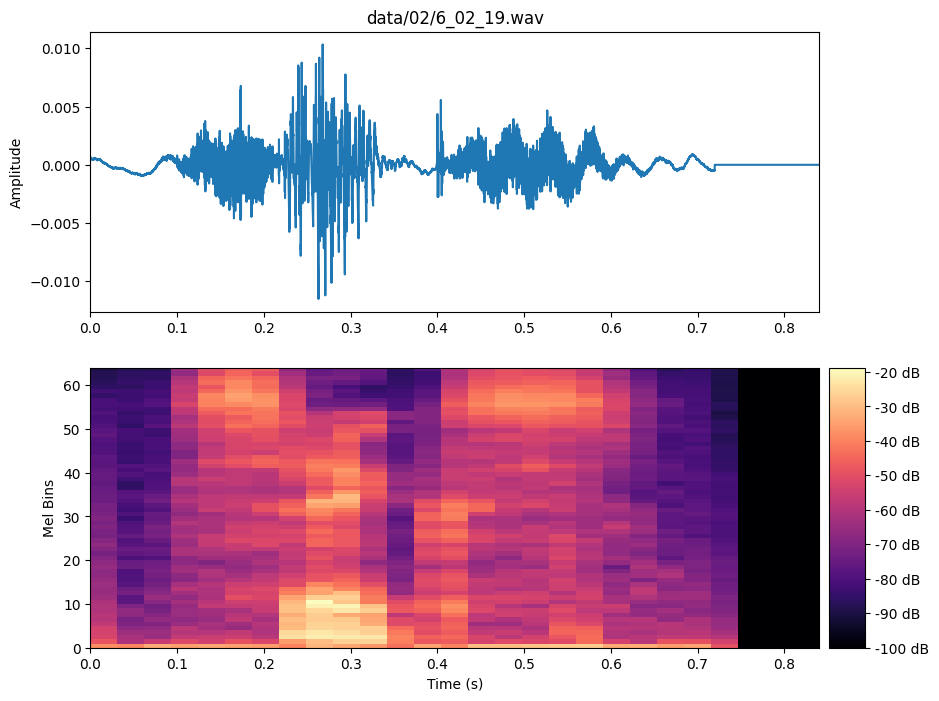

Original: 34545 samples (0.72s)
Preprocessed: 13440 samples (0.84s)


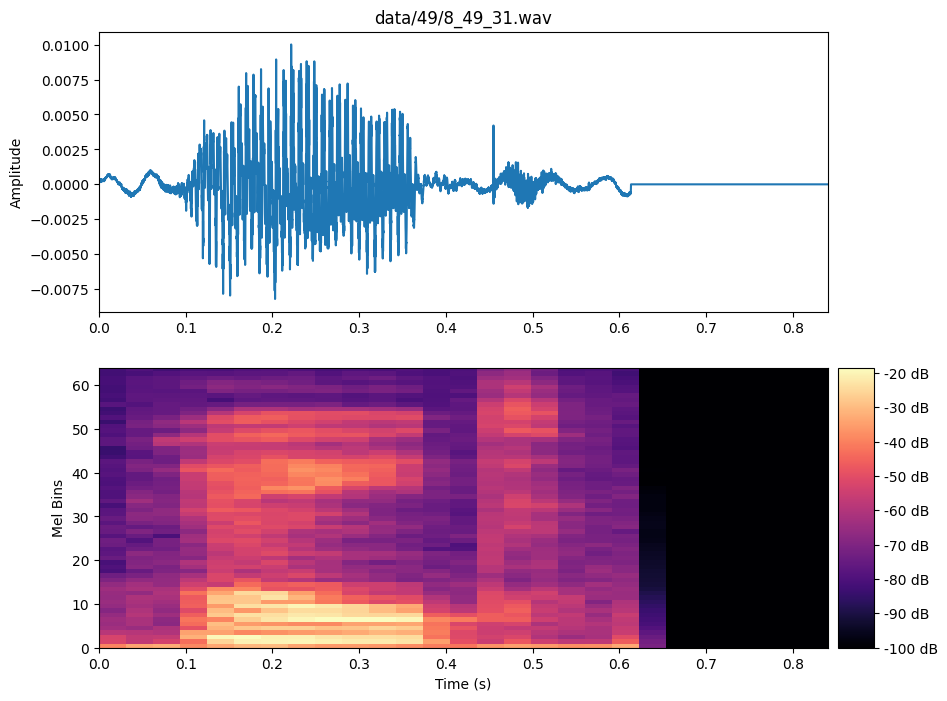

Original: 29432 samples (0.61s)
Preprocessed: 13440 samples (0.84s)


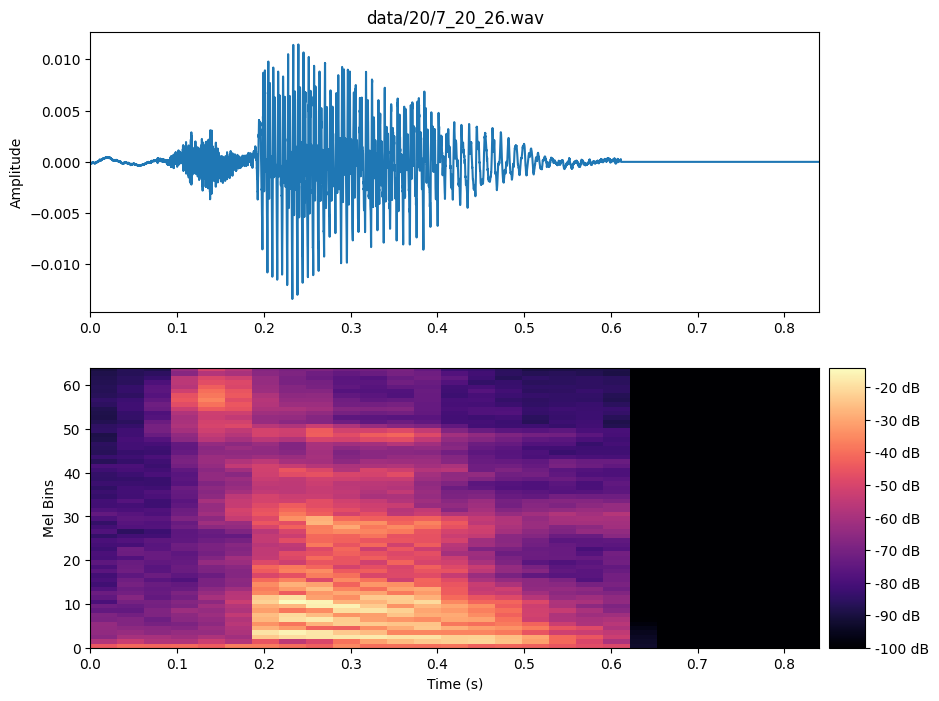

Original: 29359 samples (0.61s)
Preprocessed: 13440 samples (0.84s)


In [45]:
def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer()
    spectrogram_transformer = get_spectrogram_transformer()

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / TARGET_SAMPLE_RATE

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, NUM_MELS],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.show()

        display(Audio(data=new_waveform, rate=TARGET_SAMPLE_RATE))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')

visualise_audio_data()

### Determining the 95th percentile for audio lengths

In [46]:
# Need this to be able to determine the best time to truncate / pad to
def calculate_audio_lengths() -> None:
    audio_files = glob.glob(os.path.join(INPUT_DIR, '**/*.wav'), recursive=True)

    durations = []
    for file in tqdm(audio_files):
        info = torchaudio.info(file)
        duration = info.num_frames / info.sample_rate
        durations.append(duration)

    durations = np.array(durations)

    plt.hist(durations, bins=60)
    plt.title('Distribution of audio durations')
    plt.xlabel('Seconds')
    plt.ylabel('No. of files')
    plt.show()

    print(f'95% percentile: {np.percentile(durations, 95):.2f}s')

### Training, validation and testing code

In [47]:
def train(model, train_dataloader, optimizer, criterion) -> tuple[float, float]:
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0
    for data in tqdm(train_dataloader, desc='Training', unit='batches'):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_dataloader)
    avg_accuracy = 100 * correct / total

    return avg_loss, avg_accuracy

def validate(model, val_dataloader, criterion) -> tuple[float, float]:
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in tqdm(val_dataloader, desc='Validation', unit='batches'):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_dataloader)
    avg_accuracy = 100 * correct / total

    return avg_loss, avg_accuracy

def test(model, test_dataloader) -> float:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model = model.to(device)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data in tqdm(test_dataloader, desc='Testing', unit='batches'):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

### Training script

In [48]:
if __name__ == '__main__':
    # Define our dataset and dataloaders
    dataset = AudioDataset(data_dir=INPUT_DIR, pipeline=get_cnn_pipeline())

    # Split dataset into training, validation and test sets
    # Using an 80/10/10 split
    train_size = int(0.8 * len(dataset))
    val_size = int(0.1 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
    )

    train_dataloader = DataLoader(train_dataset, batch_size=32, num_workers=4, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=4)
    test_dataloader = DataLoader(test_dataset, batch_size=32, num_workers=4)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Train the model
    model = AudioClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # Keep track of best model
    best_accuracy = 0.0
    for epoch in range(NUM_EPOCHS):
        saved = False

        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss, train_accuracy = train(model, train_dataloader, optimizer, criterion)
        val_loss, val_accuracy = validate(model, val_dataloader, criterion)

        if val_accuracy > best_accuracy:
            saved = True
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_accuracy:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_accuracy:.2f}%')
        print()
    print(f'Best model had an accuracy of {best_accuracy:.2f}%.')
    print(f'Running final test:')
    test_accuracy = test(model, test_dataloader)
    print(f'Final test accuracy: {test_accuracy:.2f}%')

Features shape: torch.Size([32, 1, 64, 27])
Labels shape: torch.Size([32])

[Epoch 1/10]


Training:  39%|███▊      | 289/750 [00:06<00:10, 45.32batches/s]


KeyboardInterrupt: 